In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# read the csv file
df = pd.read_csv("/content/sample_data/diabetes.csv")

In [3]:
df.shape

(768, 9)

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.tail(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
758,1,106,76,0,0,37.5,0.197,26,0
759,6,190,92,0,0,35.5,0.278,66,1
760,2,88,58,26,16,28.4,0.766,22,0
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


## PERFORM EXPLORATORY DATA ANALYSIS

In [ ]:
 # Statistical summary of the dataframe
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


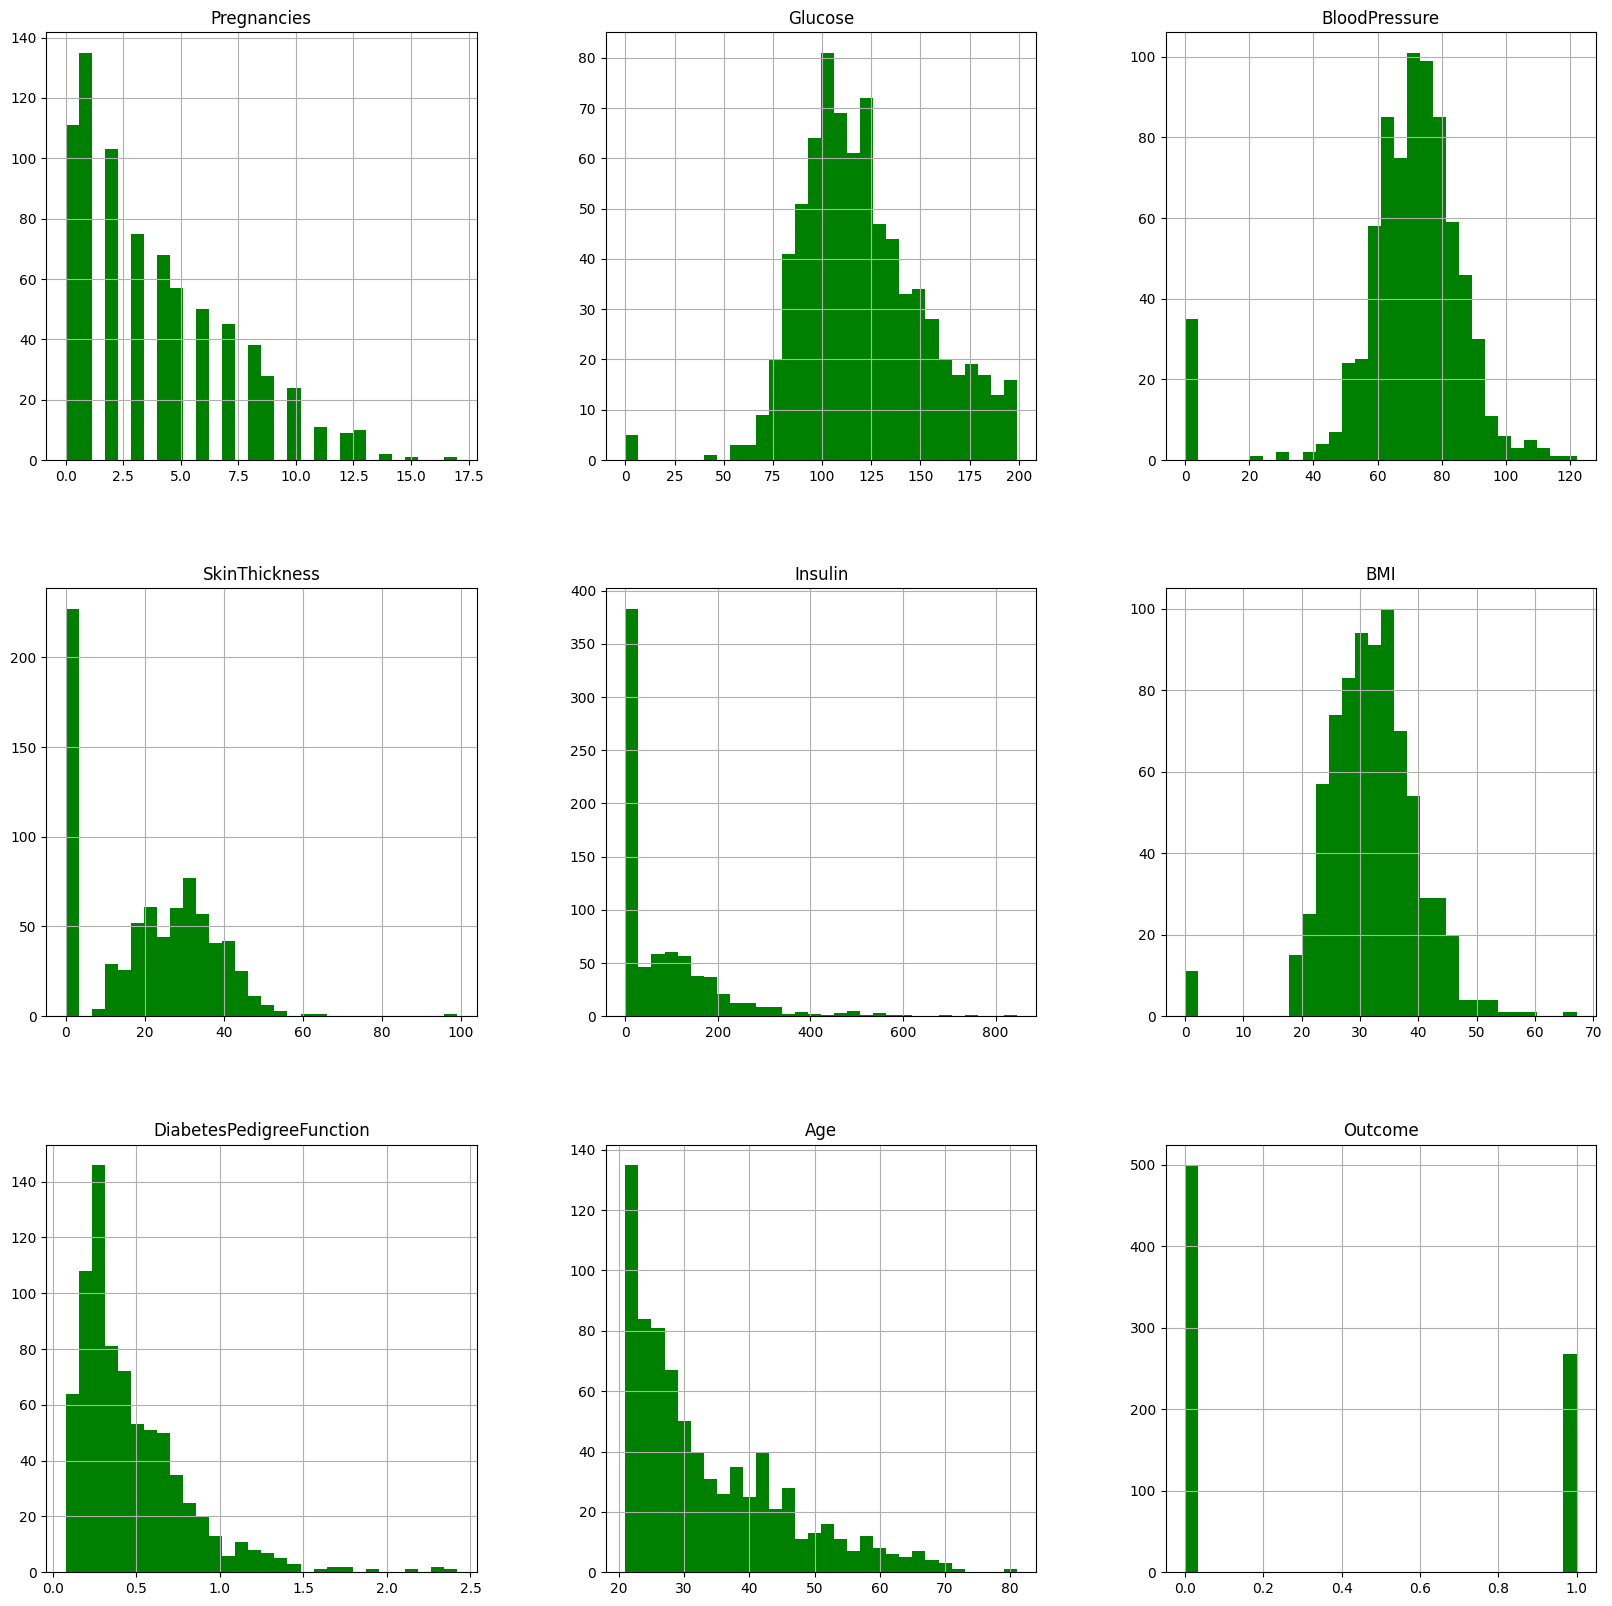

In [8]:
df.hist(bins = 30, figsize = (20,20), color = 'g')
plt.show()

In [9]:
# get the correlation matrix
corr_matrix = df.corr()
corr_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


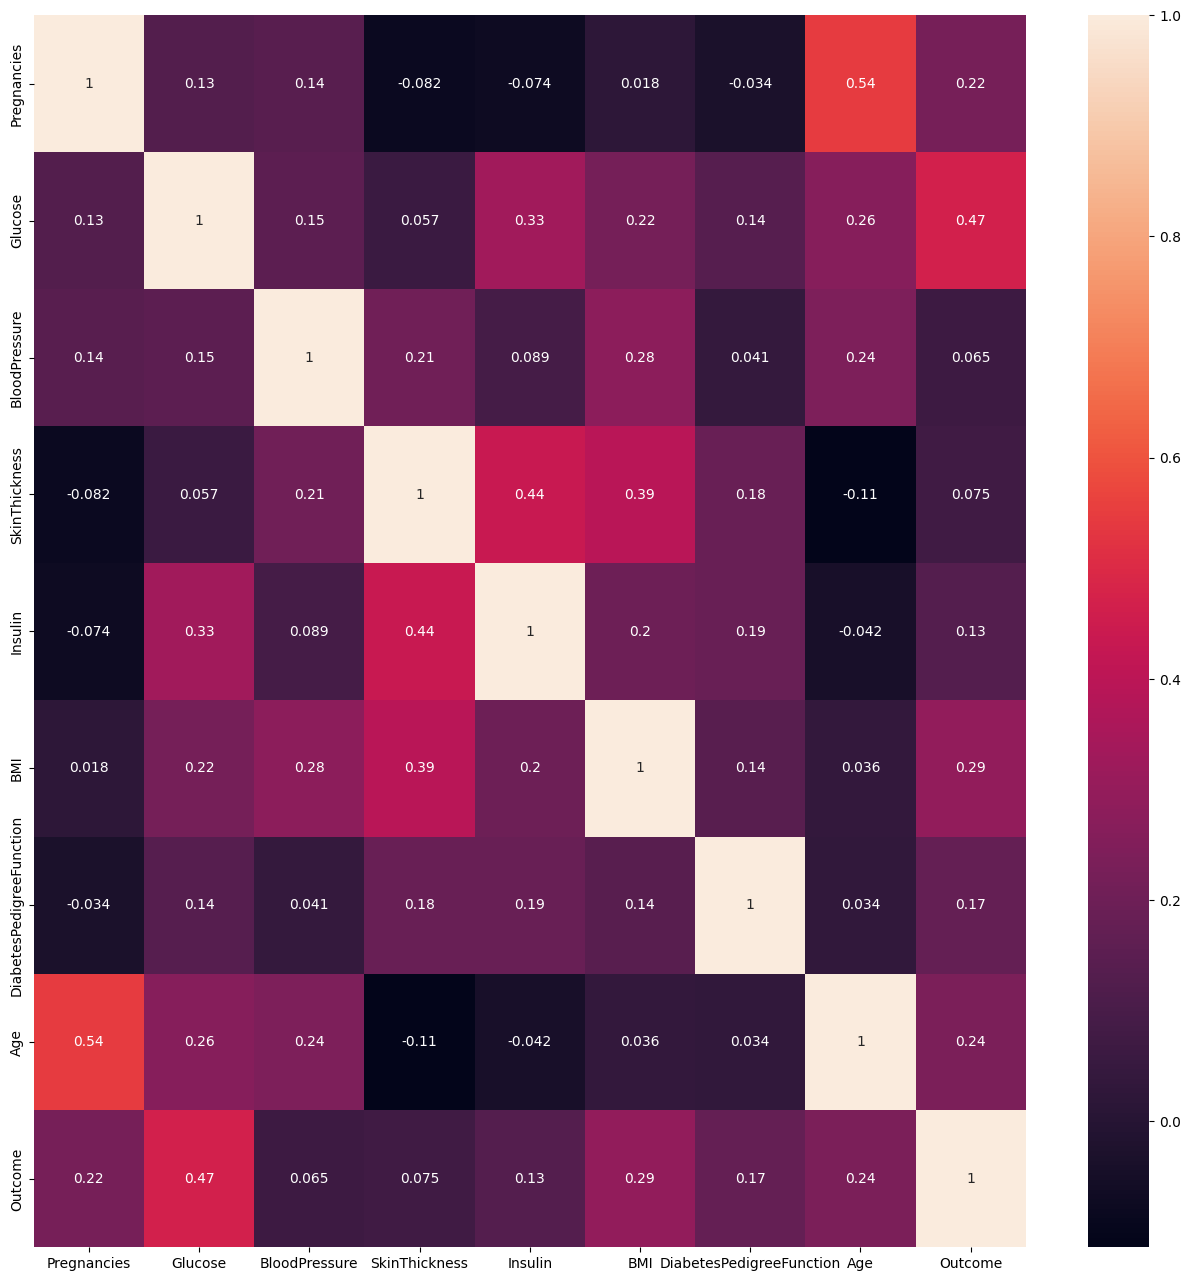

In [10]:
# plotting the correlation matrix
plt.figure(figsize = (16,16))
sns.heatmap(corr_matrix, annot = True)
plt.show()

## CREATE TRAINING AND TESTING DATASET

In [11]:
X=df.drop(columns = ["Outcome"])
y=df["Outcome"]

In [12]:
X.shape

(768, 8)

In [13]:
y.shape

(768,)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [15]:
X_train.shape, X_test.shape

((614, 8), (154, 8))

In [16]:
y_train.shape, y_test.shape

((614,), (154,))

## TRAIN AN XG-BOOST CLASSIFIER IN SK-LEARN

In [19]:
from xgboost import XGBClassifier

xgb_classifier = XGBClassifier(objective ='binary:logistic', eval_metric = 'error', learning_rate = 0.1, max_depth = 4, n_estimators = 20)
xgb_classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='error', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=20,
              n_jobs=None, num_parallel_tree=None, ...)

In [20]:
result = xgb_classifier.score(X_test, y_test)
print("Accuracy : {}".format(result))

Accuracy : 0.7792207792207793


In [21]:
y_predict = xgb_classifier.predict(X_test)
y_predict

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83        99
           1       0.71      0.65      0.68        55

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.76       154
weighted avg       0.78      0.78      0.78       154



<Axes: >

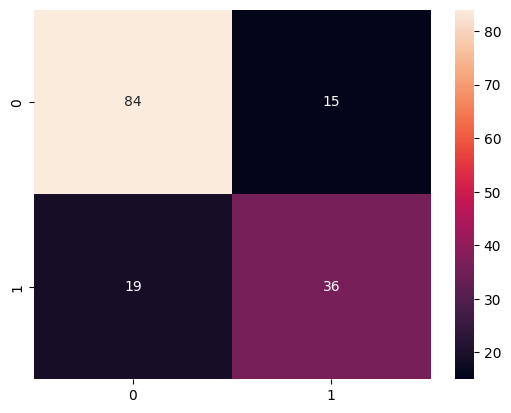

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, fmt = 'd', annot = True)

## Handle Class Imbalance with `scale_pos_weight`

Another approach to handle class imbalance in XGBoost is to use the `scale_pos_weight` parameter. This parameter is used to balance the positive and negative weights, useful for unbalanced classes. A typical value to use is `sum(negative instances) / sum(positive instances)`.

By increasing the weight of the minority class, the model is penalized more for misclassifying the positive examples, thereby encouraging it to improve recall for the positive class.

In [33]:
# Calculate the scale_pos_weight
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

print(f"Negative instances in training data: {neg_count}")
print(f"Positive instances in training data: {pos_count}")
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

Negative instances in training data: 401
Positive instances in training data: 213
Calculated scale_pos_weight: 1.88


### Retrain XGBoost Classifier with `scale_pos_weight`

In [34]:
from xgboost import XGBClassifier

# Initialize and train the XGBoost classifier with scale_pos_weight
xgb_classifier_weighted = XGBClassifier(
    objective='binary:logistic',
    eval_metric='error',
    learning_rate=0.1,
    max_depth=4,
    n_estimators=20,
    scale_pos_weight=scale_pos_weight_value, # Apply the calculated weight
    random_state=42
)
xgb_classifier_weighted.fit(X_train, y_train)

# Make predictions on the original test set
y_predict_weighted = xgb_classifier_weighted.predict(X_test)

### Evaluate Model Performance After Applying `scale_pos_weight`

Classification Report after applying scale_pos_weight:
              precision    recall  f1-score   support

           0       0.85      0.70      0.77        99
           1       0.59      0.78      0.67        55

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.76      0.73      0.73       154



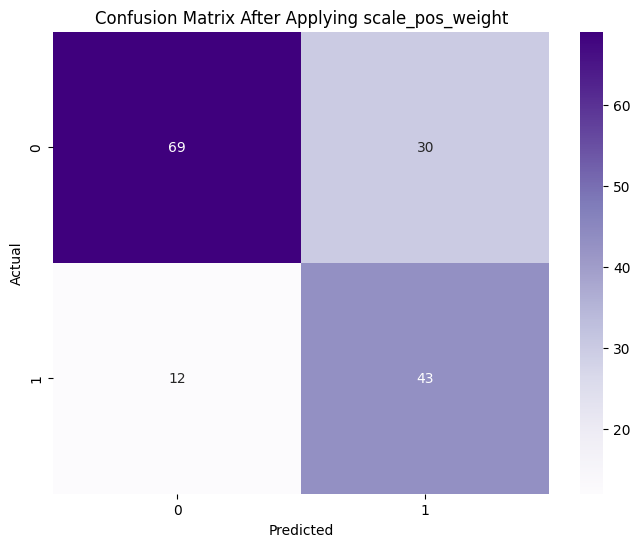

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Print classification report
print("Classification Report after applying scale_pos_weight:")
print(classification_report(y_test, y_predict_weighted))

# Plot confusion matrix
cm_weighted = confusion_matrix(y_test, y_predict_weighted)
plt.figure(figsize = (8,6))
sns.heatmap(cm_weighted, annot = True, fmt = 'd', cmap = 'Purples')
plt.title('Confusion Matrix After Applying scale_pos_weight')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Handle Class Imbalance with SMOTE

Class imbalance occurs when the number of samples in one class is significantly lower than in other classes. In our case, the 'Outcome' variable (diabetes) might be imbalanced, potentially leading the model to perform poorly on the minority class.

To address this, we will use **SMOTE (Synthetic Minority Over-sampling Technique)**, which generates synthetic samples for the minority class to balance the dataset. This helps the model learn more effectively from the underrepresented class.

In [24]:
# Install imbalanced-learn library if not already installed
!pip install imbalanced-learn

In [25]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled training set shape: {X_train_smote.shape}, {y_train_smote.shape}")
print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())

Original training set shape: (614, 8), (614,)
Resampled training set shape: (802, 8), (802,)
Class distribution after SMOTE:
Outcome
0    401
1    401
Name: count, dtype: int64


### Retrain XGBoost Classifier with SMOTE-augmented Data

In [26]:
from xgboost import XGBClassifier

# Initialize and train the XGBoost classifier with the resampled data
xgb_classifier_smote = XGBClassifier(objective ='binary:logistic', eval_metric = 'error', learning_rate = 0.1, max_depth = 4, n_estimators = 20)
xgb_classifier_smote.fit(X_train_smote, y_train_smote)

# Make predictions on the original test set
y_predict_smote = xgb_classifier_smote.predict(X_test)

### Evaluate Model Performance After SMOTE

Classification Report after SMOTE:
              precision    recall  f1-score   support

           0       0.85      0.71      0.77        99
           1       0.60      0.78      0.68        55

    accuracy                           0.73       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.73      0.74       154



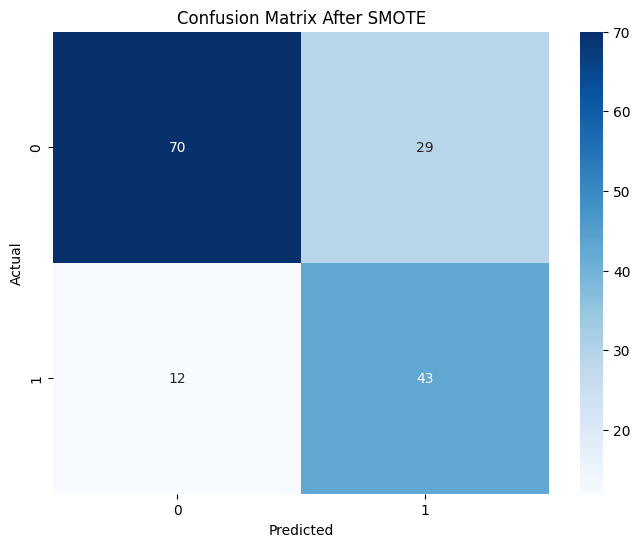

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Print classification report
print("Classification Report after SMOTE:")
print(classification_report(y_test, y_predict_smote))

# Plot confusion matrix
cm_smote = confusion_matrix(y_test, y_predict_smote)
plt.figure(figsize = (8,6))
sns.heatmap(cm_smote, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix After SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature Importance from SMOTE-augmented XGBoost Model

Understanding feature importance helps in identifying which input variables are most impactful in predicting the outcome. We will visualize these importances from the `xgb_classifier_smote` model.

/tmp/ipykernel_727/977892001.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


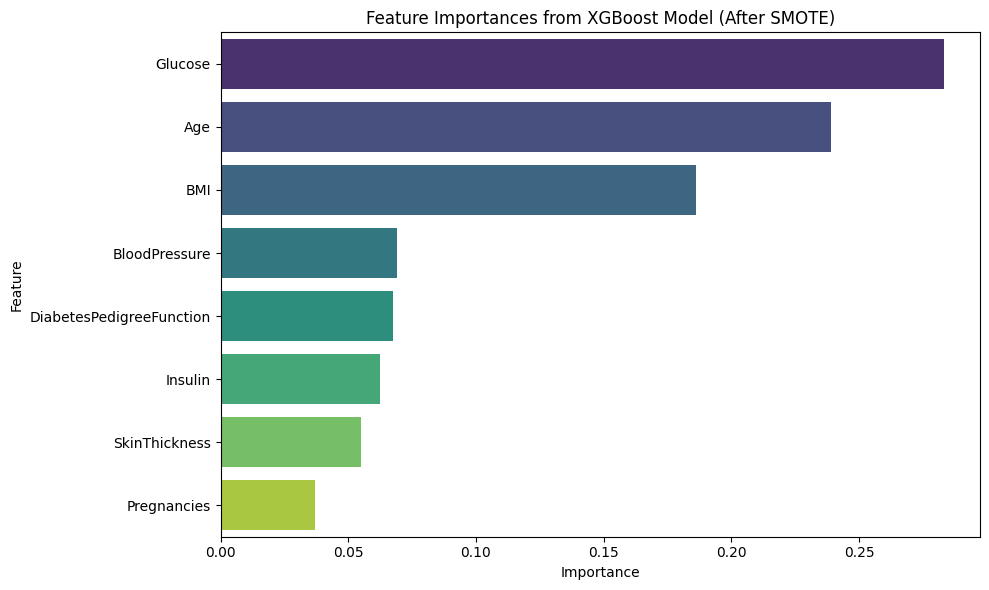

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the retrained XGBoost model
feature_importances = xgb_classifier_smote.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances from XGBoost Model (After SMOTE)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning with GridSearchCV

To further optimize the performance of our XGBoost classifier, we will use `GridSearchCV`. This method systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which mix of parameters works best.

We will define a grid of hyperparameters to search over and then fit the `GridSearchCV` object to our SMOTE-augmented training data (`X_train_smote`, `y_train_smote`).

In [29]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize the XGBoost classifier (using the same objective and eval_metric as before)
xgb = XGBClassifier(objective='binary:logistic', eval_metric='error', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='recall', # Optimize for recall on the minority class
    cv=3,
    verbose=1,
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the SMOTE-augmented training data
print("Starting GridSearchCV...")
grid_search.fit(X_train_smote, y_train_smote)
print("GridSearchCV completed.")

Starting GridSearchCV...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
GridSearchCV completed.


### Best Parameters and Score

After `GridSearchCV` completes, we can retrieve the best hyperparameters found and the corresponding best score (recall in this case).

In [30]:
# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best recall score: {grid_search.best_score_:.4f}")

# Get the best estimator
best_xgb_smote = grid_search.best_estimator_

Best parameters found: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best recall score: 0.8677


### Evaluate Tuned Model Performance

Now, let's evaluate the performance of the XGBoost model with the tuned hyperparameters on the original test set.

Classification Report after Hyperparameter Tuning (SMOTE + GridSearchCV):
              precision    recall  f1-score   support

           0       0.83      0.69      0.75        99
           1       0.57      0.75      0.65        55

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.71       154



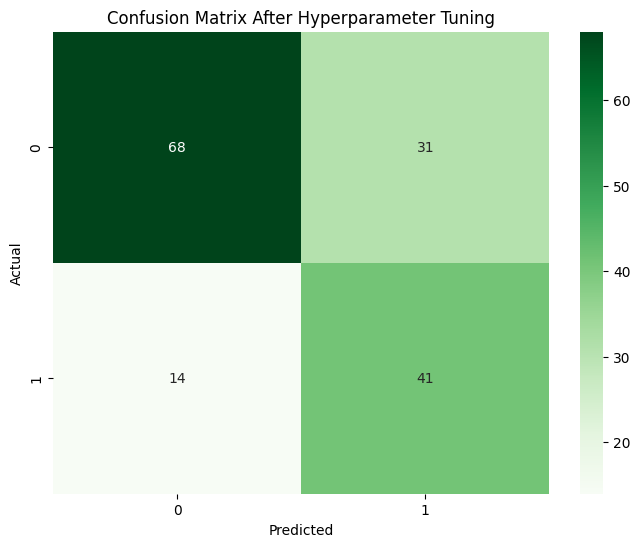

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


y_predict_tuned = best_xgb_smote.predict(X_test)

print("Classification Report after Hyperparameter Tuning (SMOTE + GridSearchCV):")
print(classification_report(y_test, y_predict_tuned))

# Plot confusion matrix
cm_tuned = confusion_matrix(y_test, y_predict_tuned)
plt.figure(figsize = (8,6))
sns.heatmap(cm_tuned, annot = True, fmt = 'd', cmap = 'Greens')
plt.title('Confusion Matrix After Hyperparameter Tuning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Visualize ROC Curve

The ROC (Receiver Operating Characteristic) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The AUC (Area Under the Curve) provides an aggregate measure of performance across all possible classification thresholds. A higher AUC indicates a better model.

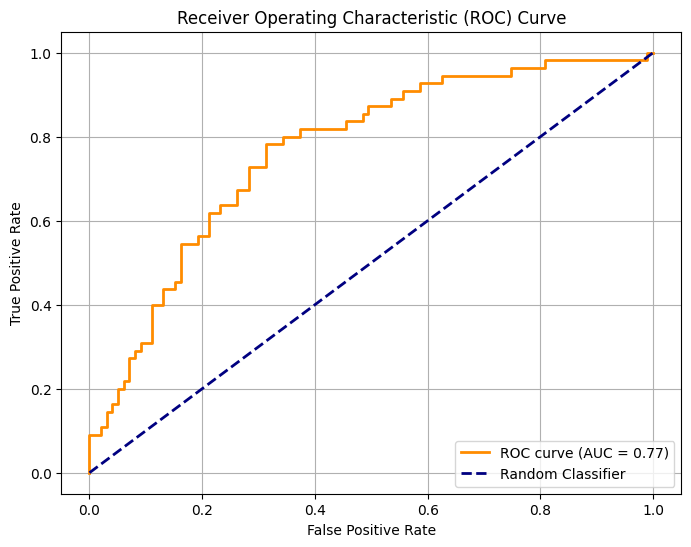

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_tuned = best_xgb_smote.predict_proba(X_test)[:, 1]

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_tuned)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba_tuned)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()